# Amazon Phone Historical Price + Monthly Sales Analysis

I analysed how Apple, Samsung, and Google smartphones lose value on the Amazon US market after launch, using real price data fetched from the Keepa API across 63 submodels and roughly 878,000 weekly price records spanning 2019 to 2026. I've also analyzed monthly sales data records.

---
## Imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid')

---
## Loading the data

### Price history

The main dataset has one row per ASIN per weekly price snapshot. Let's start by looking at its structure.

In [2]:
data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

878,267 rows, 16 columns


,asin,storage_gb,color,product_grade,submodel_name,brand,generation_name,premiere_date,datetime,new_price,amazon,used_price,list_price,sales_rank,count_new,count_used
0,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-02 15:36:00,5.69,5.69,NaN,NaN,NaN,1.0,NaN
1,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-09 18:36:00,5.51,5.51,NaN,NaN,13995.0,NaN,NaN
2,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-23 10:36:00,5.69,5.69,NaN,NaN,8232.0,NaN,NaN
3,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-07-24 07:36:00,5.29,5.29,NaN,5.69,5468.0,NaN,NaN
4,B011SDYBZW,64.0,Purple,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2021-08-06 09:32:00,5.69,5.69,NaN,NaN,3205.0,NaN,NaN


A quick look at the key columns and their types:

In [3]:
df[['brand', 'generation_name', 'product_grade', 'new_price', 'datetime', 'premiere_date']].dtypes

brand                  str
generation_name        str
product_grade          str
new_price          float64
datetime               str
premiere_date          str
dtype: object

Let's check for missing values across the dataset:

In [4]:
df.isnull().sum()

asin                    0
storage_gb          19710
color                   0
product_grade           0
submodel_name           0
brand                   0
generation_name         0
premiere_date           0
datetime                0
new_price               0
amazon             816489
used_price         727802
list_price         868356
sales_rank         461927
count_new          542322
count_used         757122
dtype: int64

A few things I noticed straight away:

- `new_price` values look suspiciously small. A value of `5.69` for an iPhone is not $5.69. After checking the Keepa docs, prices in the CSV export are stored divided by 100, so I need to multiply by 100 to get the correct USD value.
- `datetime` and `premiere_date` are strings, not datetime objects. I'll convert those.
- `premiere_date` is Keepa's tracking start date, not the actual retail launch. For price decay analysis I need the real launch date, so I'll replace it with a manually sourced reference table.
- Heavy nulls in `amazon`, `used_price`, `list_price`, `sales_rank` are expected and won't affect this analysis - I will be focusing on the `new_price`.

Let's also check what brands and product grades we're working with:

In [5]:
print(df['brand'].value_counts())
print()
print(df['product_grade'].value_counts())

apple_check_df = df[df['brand'] == 'Apple']
print(apple_check_df['product_grade'].value_counts())

samsung_check_df = df[df['brand'] == 'Samsung']
print(samsung_check_df['product_grade'].value_counts())

google_check_df = df[df['brand'] == 'Google']
print(google_check_df['product_grade'].value_counts())

brand
Apple      616537
Samsung    190786
Google      70944
Name: count, dtype: int64

product_grade
Renewed            533338
New                223114
Renewed Premium    109511
Unlocked            12304
Name: count, dtype: int64
product_grade
Renewed            470681
Renewed Premium    109496
New                 24056
Unlocked            12304
Name: count, dtype: int64
product_grade
New        170588
Renewed     20198
Name: count, dtype: int64
product_grade
Renewed            42459
New                28470
Renewed Premium       15
Name: count, dtype: int64


Apple is the only brand with a Renewed Premium grade (Google has 15 Renewed Premium cases, negligible) and most of Apple's records are non-New smartphones, with only about 3.8% of listings being New. This is important to note for later and it becomes clear that the Amazon market focuses mostly on used phones.

Samsung and Google only appear as standard Renewed, with considerably more New smartphones as well, and the difference here is huge. Samsung's listings on Amazon are new phones in 90% of the cases, and Google is sold as New in about 40% of cases. This major difference is worth a closer look before deciding how to handle it.

### Official launch prices

At first I used the first price fetched from Keepa as the launch price, but in the end I manually compiled this reference table from official press releases. It has one row per submodel with the retail launch price and the actual premiere date.

In [6]:
original_launch_ref = pd.read_csv('../data/official_launch_prices.csv')

print(f"{original_launch_ref.shape[0]} submodels")
original_launch_ref.head(10)

64 submodels


,submodel_name,official_launch_price,official_premiere_date
0,iPhone 11,766,2019-09-20
1,iPhone 11 Pro,1166,2019-09-20
2,iPhone 11 Pro Max,1266,2019-09-20
3,iPhone 12 Mini,766,2020-11-13
4,iPhone 12,849,2020-10-23
5,iPhone 12 Pro,1099,2020-10-23
6,iPhone 12 Pro Max,1199,2020-11-13
7,iPhone 13,929,2021-09-24
8,iPhone 13 Mini,829,2021-09-24
9,iPhone 13 Pro,1224,2021-09-24


The launch price is the mean across all storage configurations at retail launch (e.g. iPhone 16 Pro = mean of 128GB, 256GB, 512GB, 1TB prices). I'll use `official_premiere_date` from this table as the anchor for all price decay calculations, rather than Keepa's tracking start date which can lag by weeks or months.

### Monthly sold

This file contains Keepa's sales estimate data. Let's look at what we're working with.

In [7]:
ms_df = pd.read_csv('../data/monthly_sold_full.csv')

print(f"{ms_df.shape[0]} rows, {ms_df.shape[1]} columns")
ms_df.head()

18489 rows, 8 columns


,asin,product_grade,submodel_name,brand,generation_name,premiere_date,datetime,monthly_sold
0,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2023-10-20 07:04:00,50
1,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2023-11-28 13:34:00,100
2,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-01 08:42:00,50
3,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-01 18:16:00,100
4,B011SDYBZW,Renewed Premium,iPhone 11,Apple,iPhone 11,2019-09-20,2024-01-02 14:56:00,50


In [8]:
ms_df['monthly_sold'].value_counts().sort_index().head(15)

monthly_sold
-1        547
 50      2414
 100     3497
 200     3129
 300     2644
 400     2394
 500     1875
 1000     999
 2000     546
 3000     242
 4000     110
 5000      47
 6000      10
 7000      21
 8000      14
Name: count, dtype: int64

IMPORTANT: The `monthly_sold` values are not exact unit counts. Keepa assigns each ASIN a sales estimate bucket: `50` means 50-99 units sold, `100` means 100-499, and so on. Precise sales volumes aren't possible to calculate from this. I'll use these as relative indicators only, and I'll need to be careful about how I aggregate across ASINs. More on that in the sales pipeline section.

In [9]:
ms_df.isnull().sum()

asin               0
product_grade      0
submodel_name      0
brand              0
generation_name    0
premiere_date      0
datetime           0
monthly_sold       0
dtype: int64

---
## Price data pipeline

### Step 1: Merge with official launch prices

I join the price history with the launch reference table on `submodel_name`. This brings in `official_launch_price` and `official_premiere_date`, and also converts the date columns to proper datetime objects.

In [10]:
df = df.merge(original_launch_ref, on='submodel_name')

df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Rows after merge: {df.shape[0]}")
df[['submodel_name', 'brand', 'datetime', 'official_premiere_date', 'official_launch_price']].head()

Rows after merge: 878267


,submodel_name,brand,datetime,official_premiere_date,official_launch_price
0,iPhone 11,Apple,2021-07-02 15:36:00,2019-09-20,766
1,iPhone 11,Apple,2021-07-09 18:36:00,2019-09-20,766
2,iPhone 11,Apple,2021-07-23 10:36:00,2019-09-20,766
3,iPhone 11,Apple,2021-07-24 07:36:00,2019-09-20,766
4,iPhone 11,Apple,2021-08-06 09:32:00,2019-09-20,766


### Step 2: Core metrics

Three columns power every price decay chart:

- **`days_since_launch`**: days between the price snapshot and the official retail premiere. I filter out rows where this is 0 or negative, as these represent pre-launch tracking noise.
- **`NEW`**: price in USD. Keepa stores prices divided by 100 in the export, so multiplying by 100 gives the correct dollar value (e.g. `5.69` raw becomes `$569.00`).
- **`price_pct_of_launch`**: `NEW / official_launch_price * 100`. This is the main metric throughout the analysis. 100% means the phone is still at its launch price, 50% means it has lost half its value.
- **`days_rounded`**: days rounded to the nearest 7. Without this, ASINs with slightly different snapshot timestamps create separate disconnected line segments in Seaborn rather than a single smooth curve. Rounding to weekly buckets eliminates that artifact.
- **`tier`**: extracted by stripping the generation name from the submodel name. For example, "iPhone 13 Pro Max" becomes "Pro Max", and "iPhone 13" becomes "Base".

In [11]:
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]

df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)

df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7

df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')

print(f"Rows after filtering pre-launch: {df.shape[0]:,}")
df[['submodel_name', 'tier', 'days_since_launch', 'NEW', 'price_pct_of_launch']].head(8)

Rows after filtering pre-launch: 878,193


,submodel_name,tier,days_since_launch,NEW,price_pct_of_launch
0,iPhone 11,Base,651,569.0,74.3
1,iPhone 11,Base,658,551.0,71.9
2,iPhone 11,Base,672,569.0,74.3
3,iPhone 11,Base,673,529.0,69.1
4,iPhone 11,Base,686,569.0,74.3
5,iPhone 11,Base,687,529.0,69.1
6,iPhone 11,Base,701,569.0,74.3
7,iPhone 11,Base,704,529.0,69.1


Quick sanity check on the tier extraction:

In [12]:
df.groupby('brand')['tier'].value_counts()

brand    tier    
Apple    Base        165423
         Pro Max     158739
         Pro         146881
         Mini        108160
         Plus         37334
Google   Pro          33856
         Base         28076
         a             7189
         Pro Fold      1140
         Pro XL         641
Samsung  Base         78629
         Ultra        51109
         +            34036
         FE           26202
         Edge           778
Name: count, dtype: int64

### Step 3: Product grade check

Before building any charts, I need to understand whether New and Renewed listings price differently.

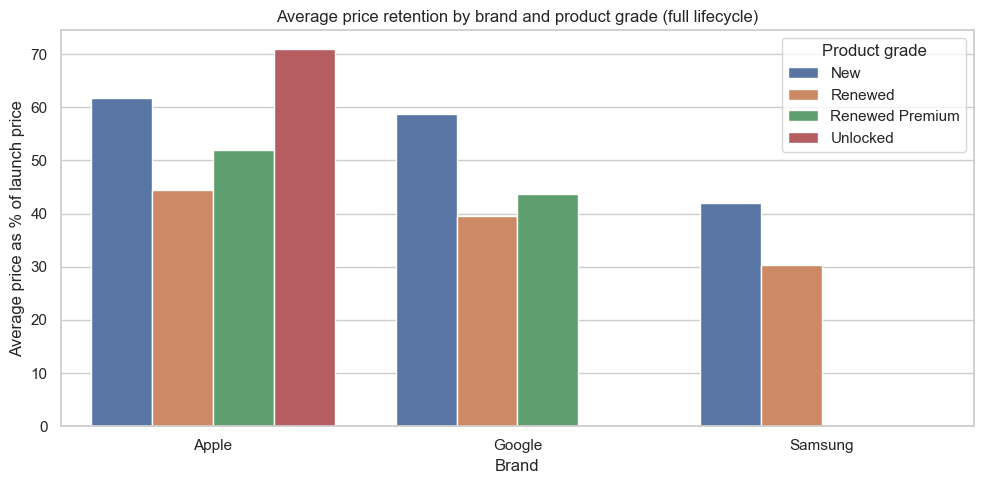

In [13]:
grade_price_df = df.groupby(['brand', 'product_grade'])['price_pct_of_launch'].mean().round(1).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=grade_price_df, x='brand', y='price_pct_of_launch', hue='product_grade', ax=ax)
ax.set_title('Average price retention by brand and product grade (full lifecycle)')
ax.set_xlabel('Brand')
ax.set_ylabel('Average price as % of launch price')
ax.legend(title='Product grade')
plt.tight_layout()
plt.show()


There seems to be a consistent gap across the three brands:

- Apple: New retains 61.8% vs Renewed at 44.4%. That is a 17pp difference.
- Samsung: New at 42.0% vs Renewed at 30.4%, a 12pp gap.
- Google: New at 58.8% vs Renewed at 39.6%, a 19pp gap.

There are slight difference, which is obvious, but for Samsung phones, excluding the New data would mean deleting about 90% of all data for that brand, and for Google about 40%.

We must read the comparisons with that in mind, but I'm not going to discard the majority of data for now.

---
## Project overview

A quick summary of the dataset before diving into the analysis.

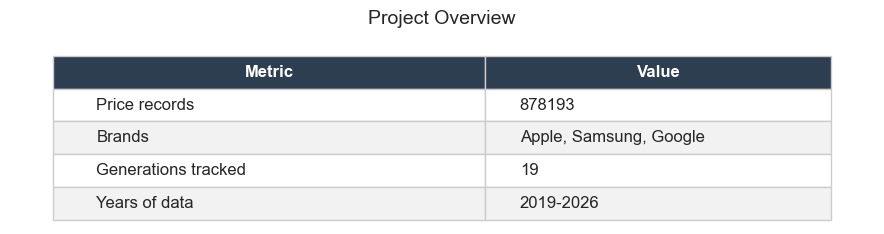

In [14]:
kpi_data = [
    ['Price records', f"{df.shape[0]}"],
    ['Brands', 'Apple, Samsung, Google'],
    ['Generations tracked', str(df['generation_name'].nunique())],
    ['Years of data', '2019-2026'],
]

fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')
table = ax.table(
    cellText=kpi_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.5, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Project Overview', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

---
# Price decay analysis

Each chart below shows price as a percentage of the official launch price over time. 100% means the phone is still at its launch price on the Renewed market, 50% means it has lost half its value. The x-axis shows days since launch so models can be compared at the same point in their lifecycle regardless of when they were released.

## Official launch prices

Before looking at decay, it helps to understand what each brand charges at launch. These prices were calculated as the mean across all storage tiers for each submodel.

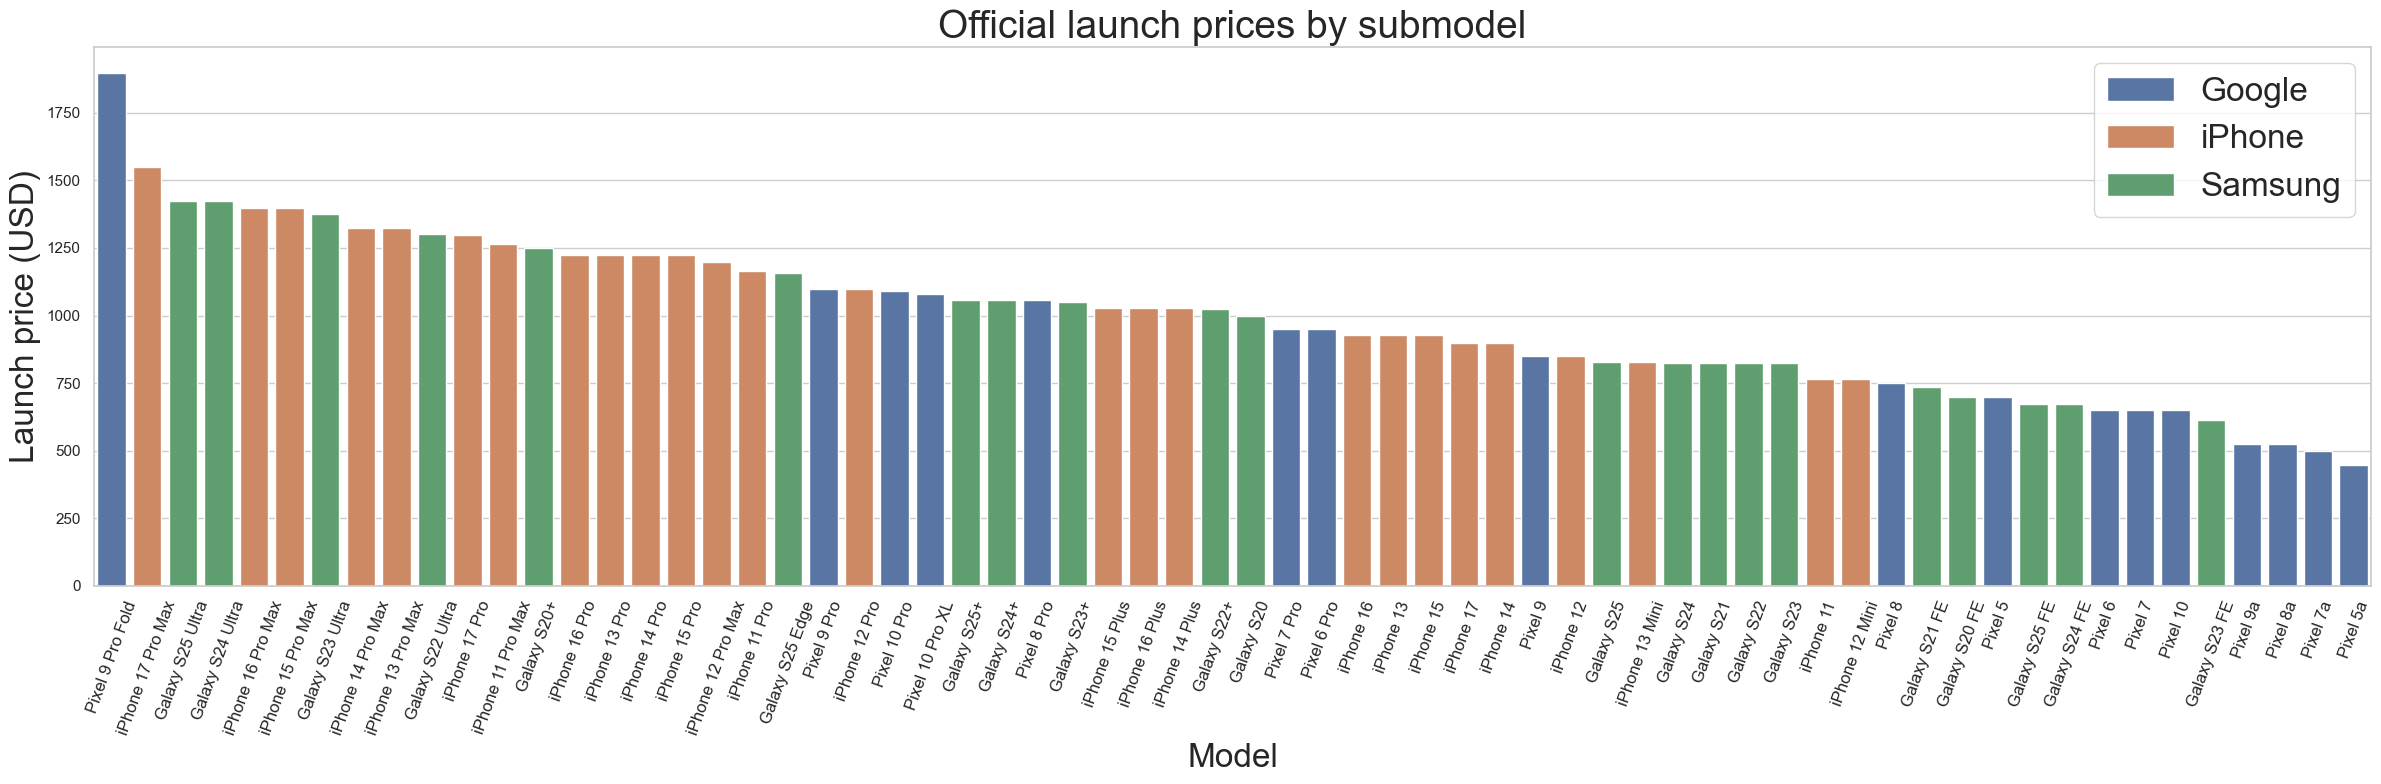

In [15]:
gen_lookup = df[['submodel_name', 'generation_name', 'brand']].drop_duplicates()
launch_ref = original_launch_ref.copy().merge(gen_lookup, on='submodel_name', how='left')

#Here I'm also adding the tier as it will be used later
#By tier I mean Base (as in base iPhone 11, Samsung Galaxy S23 etc.), Pro, Pro Max, +, Ultra etc.
launch_ref['tier'] = launch_ref.apply(
    lambda row: row['submodel_name'].replace(str(row['generation_name']), '').strip(), axis=1)
launch_ref['tier'] = launch_ref['tier'].replace('', 'Base')

#converting the date to a pandas datetime format
launch_ref['official_premiere_date'] = pd.to_datetime(launch_ref['official_premiere_date'])

#brand name fix for Pixel and Galaxy
launch_ref['brand'] = launch_ref['submodel_name'].str.split().str[0].replace(
    ['Pixel', 'Galaxy'], ['Google', 'Samsung'])

#sorting values based on their launch price in USD
launch_ref = launch_ref.sort_values('official_launch_price', ascending=False)

plt.subplots(figsize=(24, 8))
sns.barplot(data=launch_ref, x='submodel_name', y='official_launch_price', hue='brand')
plt.legend(loc='upper right', fontsize=24)
plt.xticks(rotation=70, fontsize = 12)
plt.xlabel('Model', fontsize = 24)
plt.ylabel('Launch price (USD)', fontsize = 24)
plt.title('Official launch prices by submodel', fontsize = 28)
plt.tight_layout()
plt.show()

Below is a comparison across brands over time, split by base models and flagships.

Note on Google's lineup: the Pro Fold appears in this dataset and takes the top spot by price at $1,799. It is best understood as a premium foldable form factor rather than the absolute hardware flagship. 

Its price reflects complex engineering and a flexible display, but it trades off on traditional flagship metrics. The regular Pixel Pro remains the true performance flagship for Google. Unlike the Fold, the iPhone Pro Max and Samsung Galaxy Ultra are the undisputed hardware flagships of their respective brands.

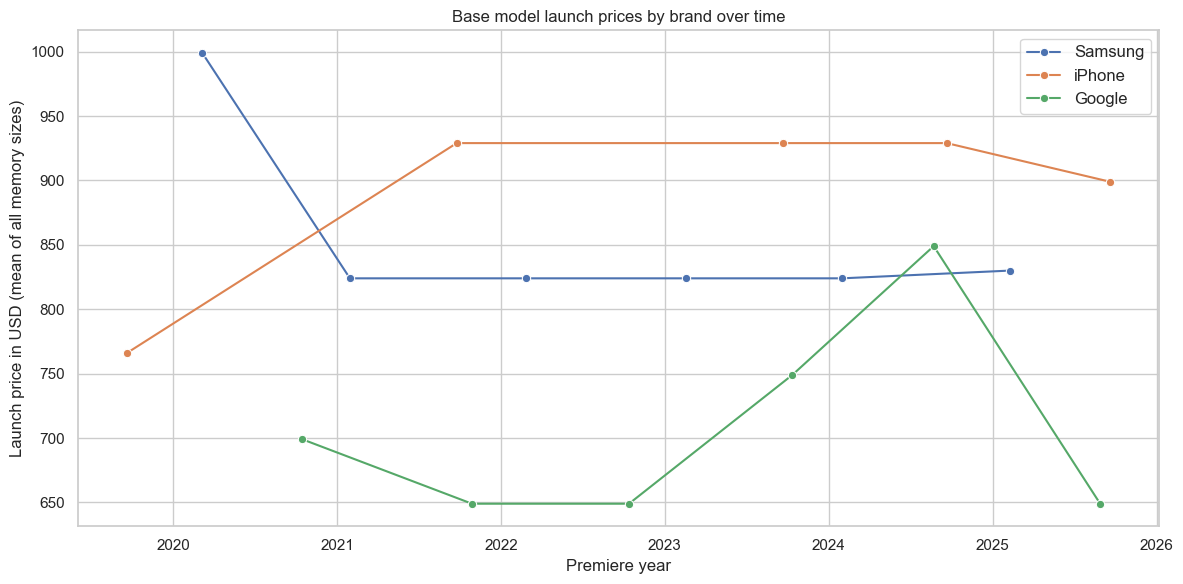

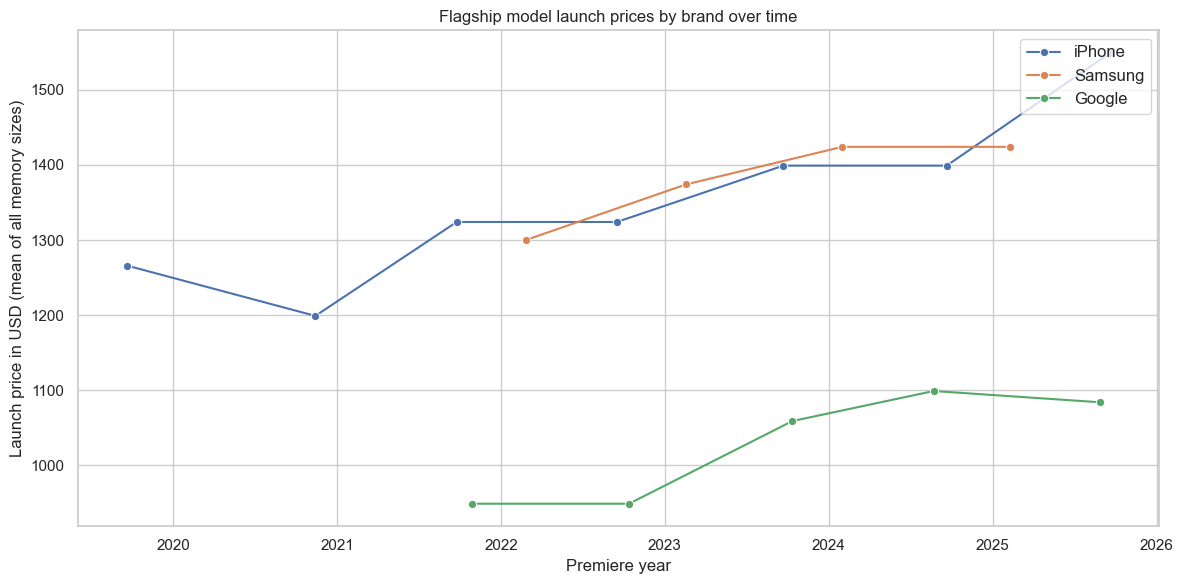

In [16]:
base_launch_ref = launch_ref[launch_ref['tier'] == 'Base']
flagship_launch_ref = launch_ref[
    (launch_ref['tier'] == 'Pro Max') |
    (launch_ref['tier'] == 'Ultra') |
    (launch_ref['tier'] == 'Pro XL') |
    ((launch_ref['tier'] == 'Pro') & (launch_ref['brand'] == 'Google'))
]

plt.subplots(figsize=(12, 6))
sns.lineplot(data=base_launch_ref, x='official_premiere_date', y='official_launch_price',
    hue='brand', marker='o')
plt.legend(loc='upper right', fontsize=12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Base model launch prices by brand over time')
plt.tight_layout()
plt.show()

plt.subplots(figsize=(12, 6))
sns.lineplot(data=flagship_launch_ref, x='official_premiere_date', y='official_launch_price',
    hue='brand', marker='o')
plt.legend(loc='upper right', fontsize=12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Flagship model launch prices by brand over time')
plt.tight_layout()
plt.show()

Google consistently positions itself as the most budget-friendly choice. Across both tiers, Google smartphones are generally priced about 20% lower than their competitors.

Samsung and Apple compete directly at the top of the market. Apple's base models are typically about 10% more expensive than Samsung's base models, but that gap disappears at the premium level where Samsung's Ultra models are priced almost identically to Apple's Pro Max variants.

---
## All brands combined (base models)

Starting with the broadest view: average price decay across all base models per brand.

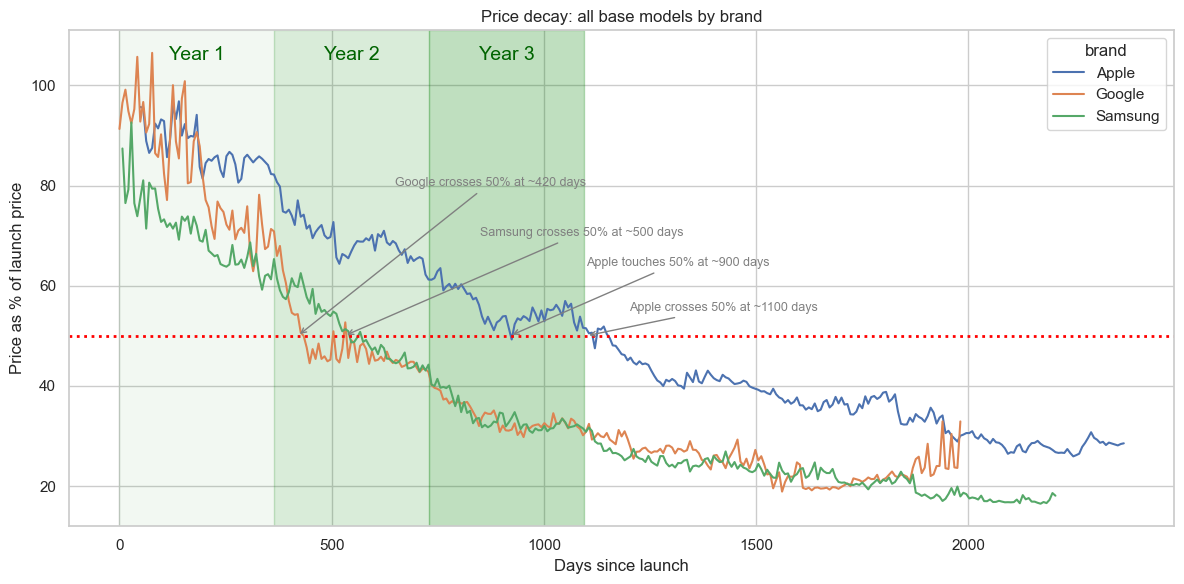

In [ ]:
base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch', hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay: all base models by brand')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.annotate('Samsung crosses 50% at ~500 days', xy=(530, 50), xytext=(850, 70),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.annotate('Apple touches 50% at ~900 days', xy=(920, 50), xytext=(1100, 64),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.annotate('Apple crosses 50% at ~1100 days', xy=(1100, 50), xytext=(1200, 55),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.annotate('Google crosses 50% at ~420 days', xy=(420, 50), xytext=(650, 80),
    arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.show()

Apple phones are the last to hit the 50% mark, getting there for the first time at around 900 days after launch and clearly crossing it at about 1100 days. Samsung reaches it at roughly 500 days, Google at around 420 days. Apple also has the highest price floor, stabilising at 26-28% of launch price after about 2000 days. Samsung bottoms out around 16-17% and Google around 20%.

---
## Price decay by product grade

Before diving into tier comparisons, it is worth understanding how listing condition affects price retention across brands. Apple has both Renewed and Renewed Premium. Samsung is predominantly New stock on Amazon, and Google sits somewhere in between.

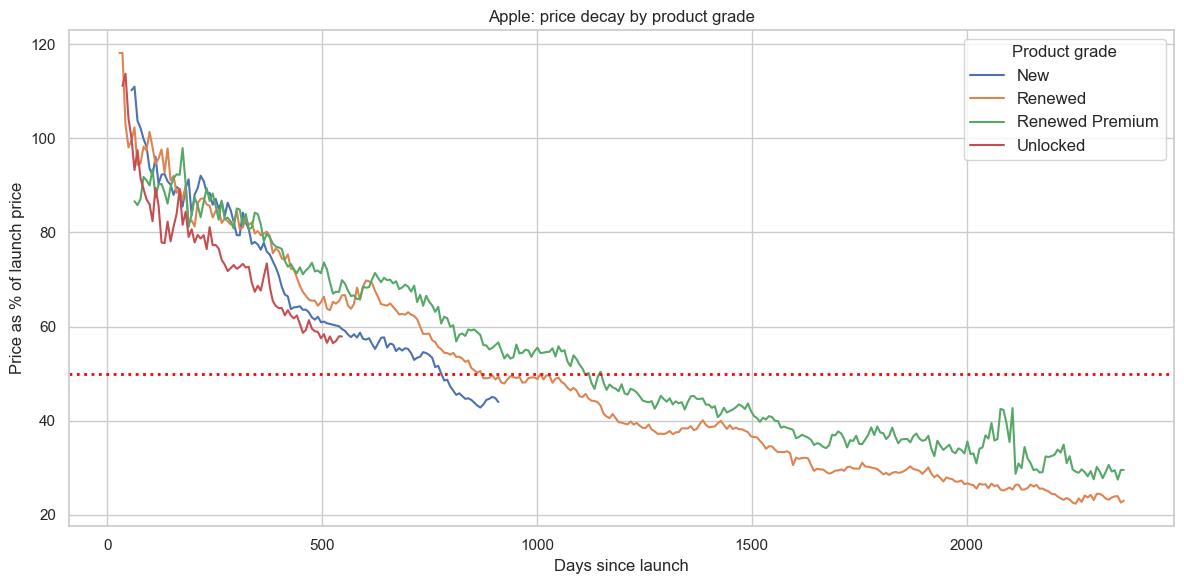

In [18]:
apple_grade_df = df[df['brand'] == 'Apple'].groupby(['product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=apple_grade_df, x='days_rounded', y='price_pct_of_launch', hue='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Apple: price decay by product grade')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(title='Product grade', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
grade_means = df[df['brand'] == 'Apple'].groupby('product_grade')['price_pct_of_launch'].mean()
gap = grade_means['Renewed Premium'] - grade_means['Renewed']
print(f'Renewed Premium vs Renewed gap: +{gap:.1f} pp')
print(grade_means.round(1))

Renewed Premium vs Renewed gap: +7.5 pp
product_grade
New                61.8
Renewed            44.4
Renewed Premium    51.9
Unlocked           70.9
Name: price_pct_of_launch, dtype: float64


Renewed Premium consistently prices above standard Renewed throughout the entire lifecycle. The gap averages around 10 percentage points and remains stable rather than narrowing over time, which suggests buyers treat it as a persistent condition premium rather than a launch-window effect.

There's also the New and Unlocked, but as we already know, they're a minority of all listings, and as the chart confirms, they seem to be performing even worse. This is perhaps due to a small data coverage.

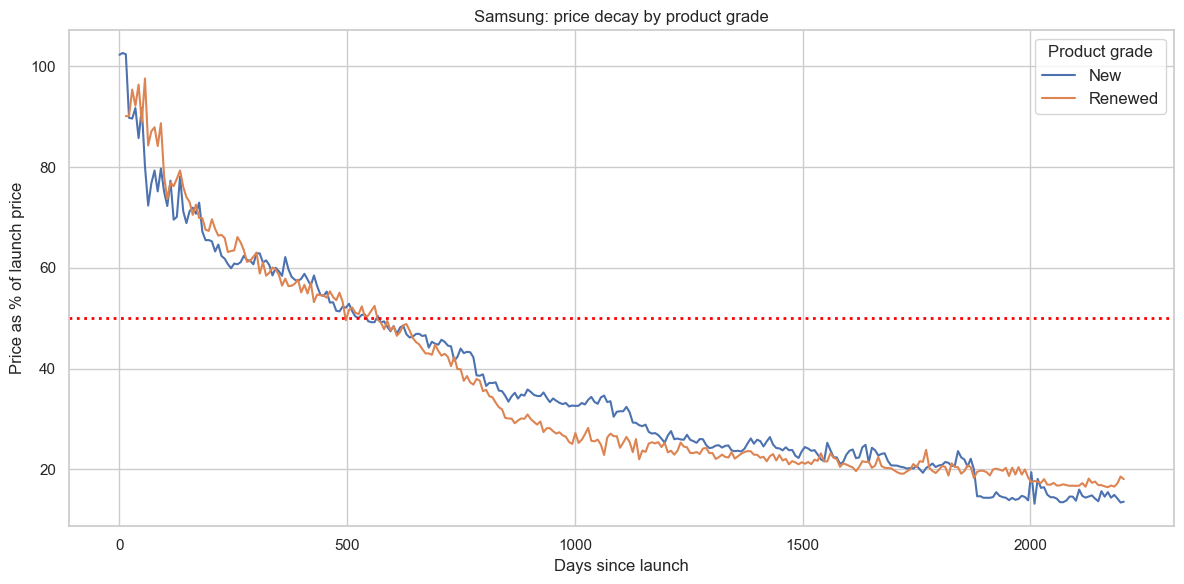

In [20]:
samsung_grade_df = df[df['brand'] == 'Samsung'].groupby(['product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=samsung_grade_df, x='days_rounded', y='price_pct_of_launch', hue='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Samsung: price decay by product grade')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(title='Product grade', fontsize=12)
plt.tight_layout()
plt.show()

Interestingly here we can see that both New and Renewed Samsung smartphones are performing in a similar way on the price decay chart.

There are periods where Renewed performs even better, and also periods when New clearly holds anove with about 5-10 pp premium, mostly around days 800-1200~. The tendency does not hold throughout the whole lifecycle, like in Apple's case.

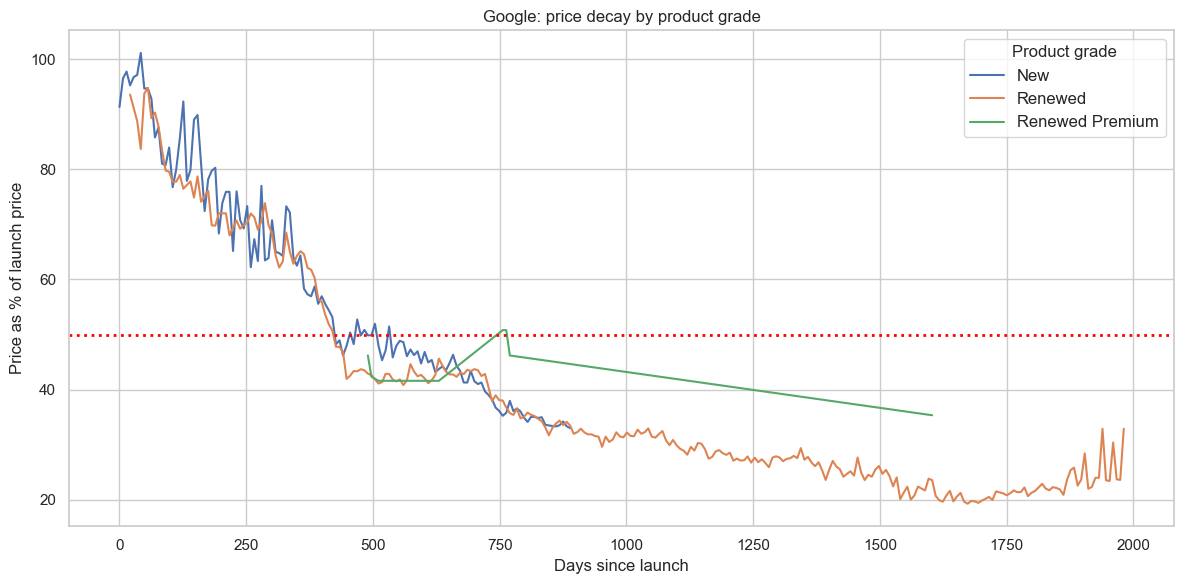

In [21]:
google_grade_df = df[df['brand'] == 'Google'].groupby(['product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=google_grade_df, x='days_rounded', y='price_pct_of_launch', hue='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Google: price decay by product grade')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(title='Product grade', fontsize=12)
plt.tight_layout()
plt.show()

Google shows a similar pattern to Samsung but with a larger spread and more volatility in the Renewed curve - this is most likely due to the fact that there are very few cases of Renewed Premium actually listed there, so data from that tier should be excluded in that particular case. Renewed listings start near 90% and decay at a pace comparable to New listings.

There are slight differences between the New and the Renewed tier here, but the curves cross each other from time to time, which is maybe a bit unexpected.

---
## Price retention at one year: by brand and generation

Instead of full decay curves per generation (too many lines to read cleanly), I take a snapshot at around 365 days post-launch and rank each generation. This directly shows which models held their value best in year one.

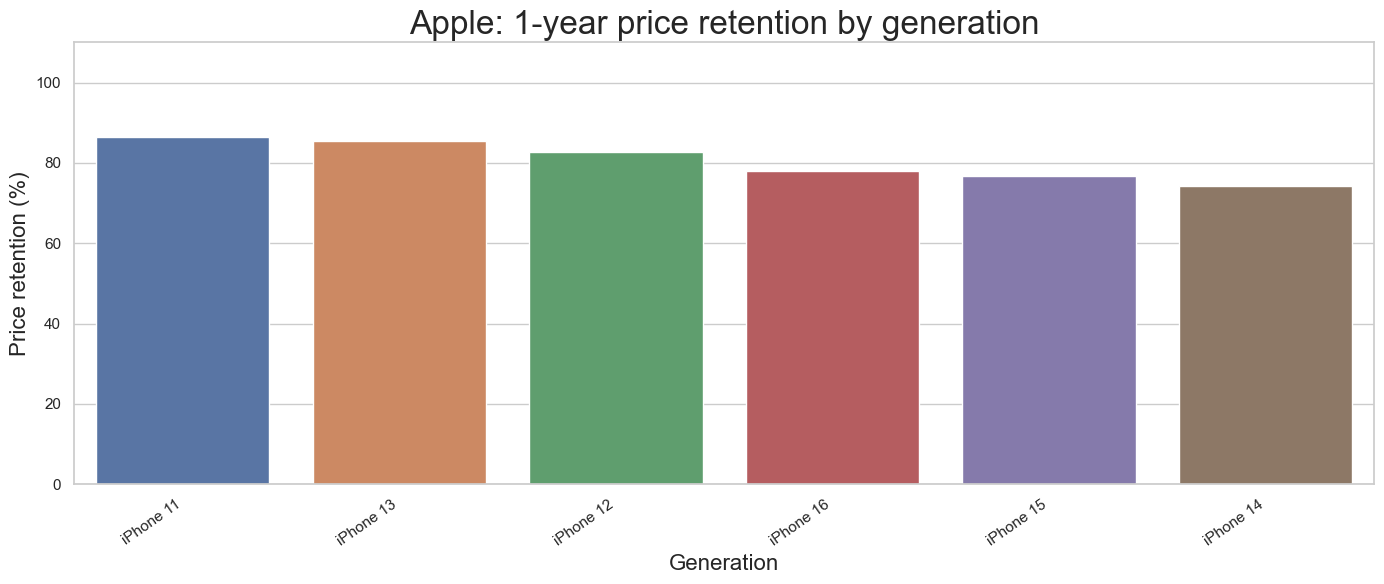

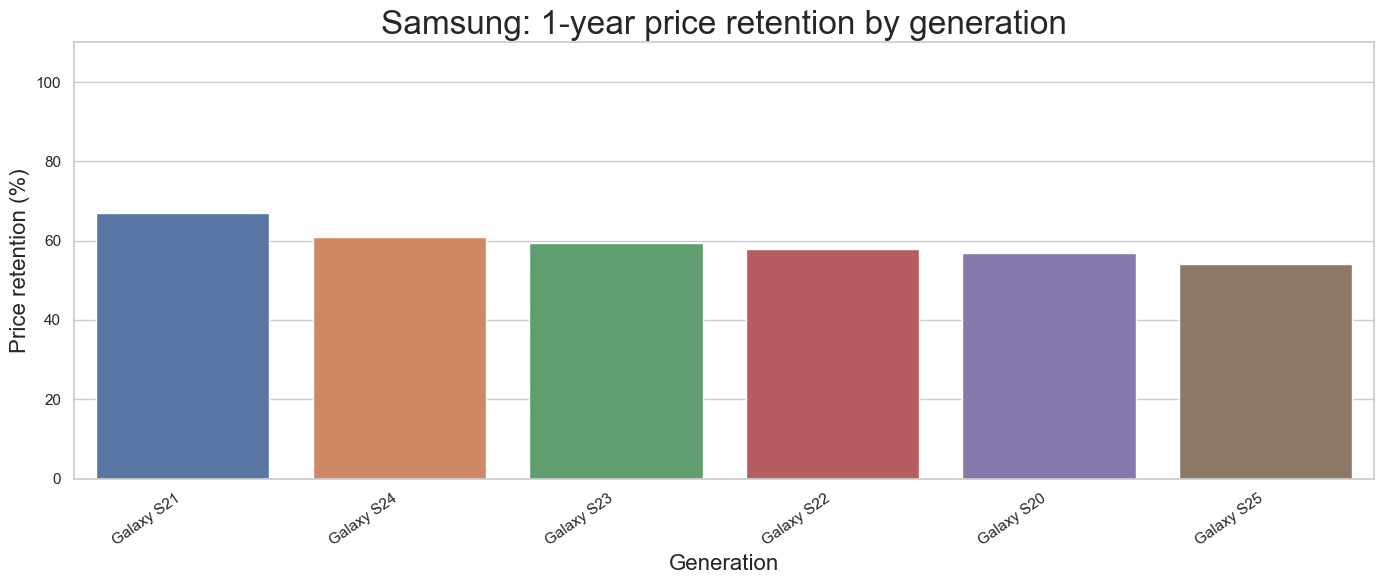

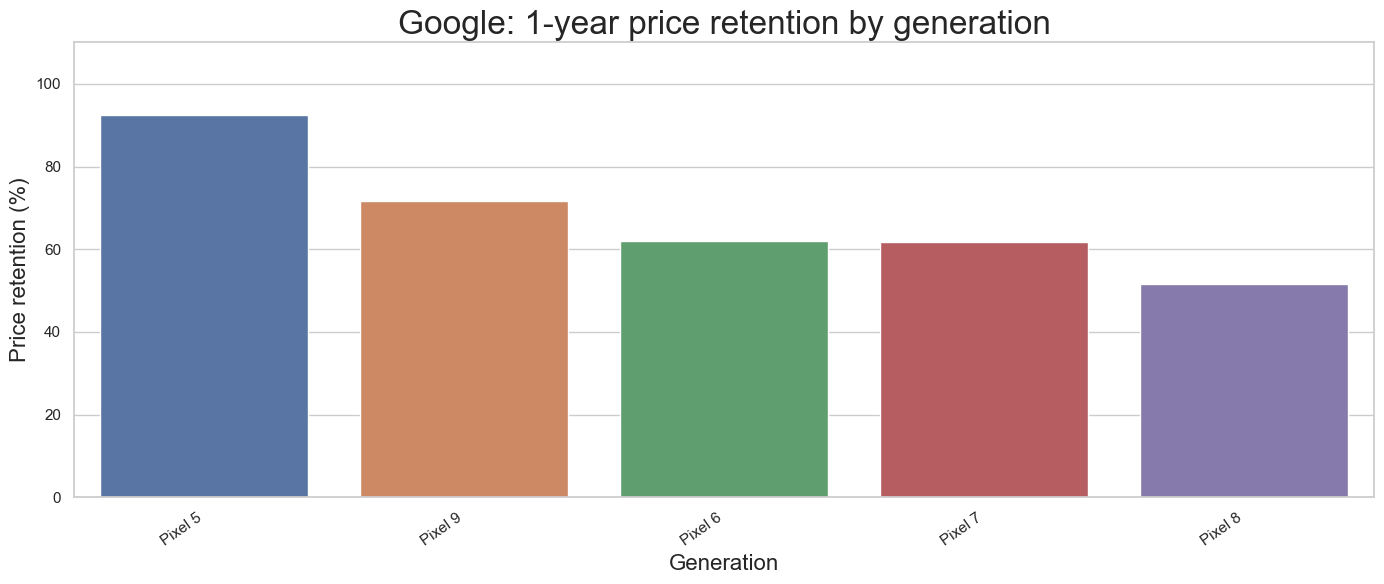

In [53]:
retention_1yr_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = retention_1yr_df.groupby(['generation_name', 'brand']).agg(
    price_retention=('price_pct_of_launch', 'mean')
).reset_index()

for brand in ['Apple', 'Samsung', 'Google']:
    brand_df = retention_1yr_df[retention_1yr_df['brand'] == brand].sort_values('price_retention', ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(
        data=brand_df,
        x='generation_name',
        y='price_retention',
        hue = 'generation_name',
        ax=ax)
    ax.set_title(f'{brand}: 1-year price retention by generation', fontsize = 24)
    ax.set_xlabel('Generation', fontsize = 16)
    ax.set_ylabel('Price retention (%)', fontsize = 16)
    ax.set_ylim(0, 110)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

Apple generations cluster tightly around 80% at the one-year mark, showing rather consistent retention across the lineup. 
Samsung shows similar spread around 55-60%. The Pixel 5 is a clear outlier among Google phones, retaining value at a level closer to iPhones than other Pixels, which sit around the 50-60% mark.

It launched at a relatively low price and was discontinued earlier than expected, which limited supply and perhaps it was the reason that kept the secondary market value elevated.

---
## Within a generation: iPhone 13 submodels

So far we have been looking at base models only. Let's go one level deeper and look at all tiers within a single generation to see how they compare against each other.

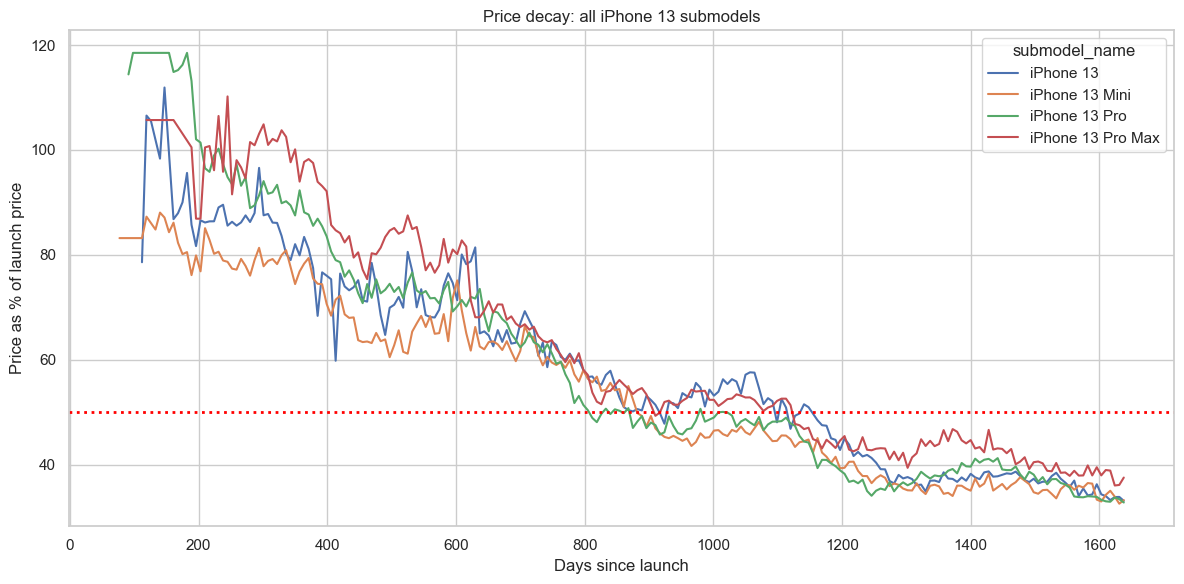

In [23]:
iphone13_decay_df = df[df['generation_name'] == 'iPhone 13'].groupby(
    ['submodel_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay: all iPhone 13 submodels')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()

The Pro Max consistently holds value best at almost every stage of the lifecycle. It retains roughly 40% of its launch price even at the 1600-day mark. The Mini depreciates fastest, which likely reflects lower consumer demand on the secondary market.

---
## Price decay by tier

Now let's look at all tiers across all generations for each brand. This gives a cleaner view of whether premium tiers hold value better or worse than the base models over time.

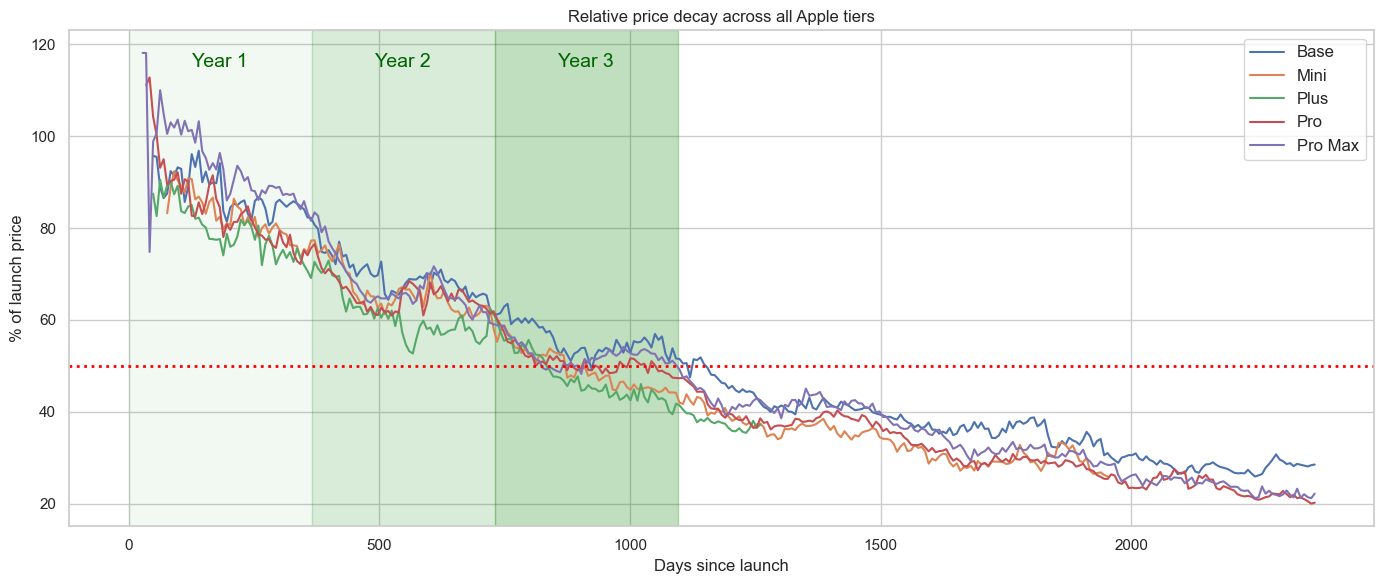

In [24]:
all_brands_tier_df = df.groupby(['brand', 'tier', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
apple_tier_df = all_brands_tier_df[all_brands_tier_df['brand'] == 'Apple']

plt.subplots(figsize=(14, 6))
sns.lineplot(apple_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Apple tiers')
plt.xlabel('Days since launch')
plt.ylabel('% of launch price')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 115, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 115, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 115, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

Contrary to what the iPhone 13 chart might suggest, the Base model shows the highest price stability across generations over the long term. The Pro Max performs well at certain intervals but does not consistently outperform the Base when averaged across all generations.

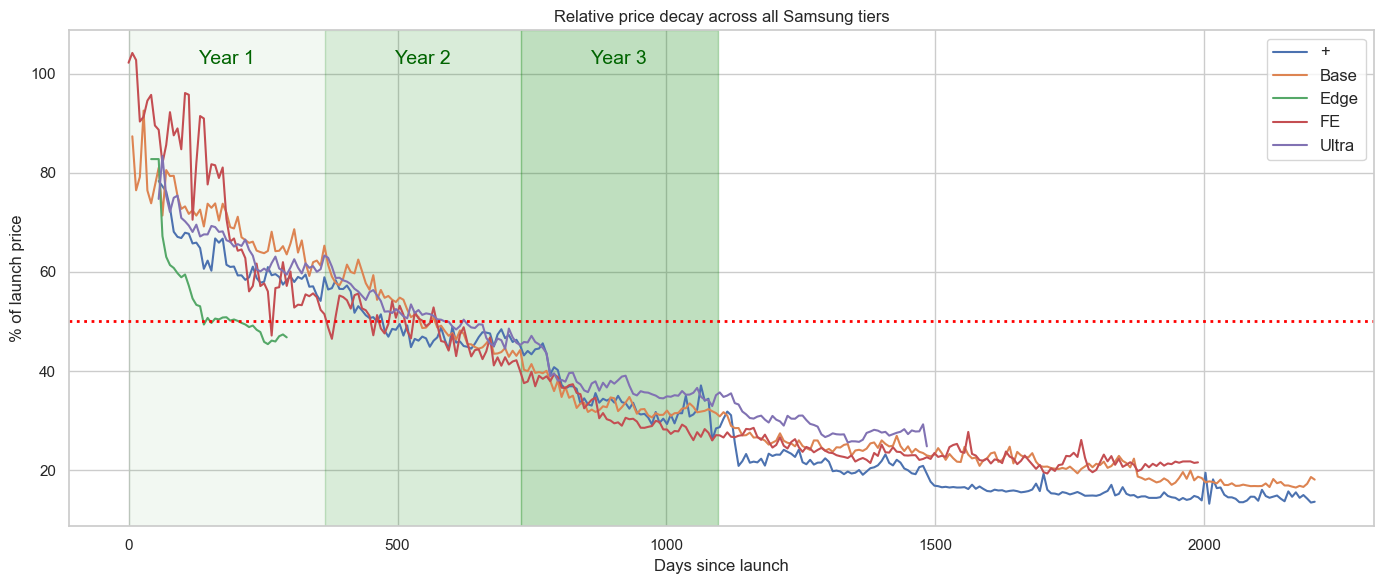

In [25]:
samsung_tier_df = all_brands_tier_df[all_brands_tier_df['brand'] == 'Samsung']

plt.subplots(figsize=(14, 6))
sns.lineplot(samsung_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Samsung tiers')
plt.xlabel('Days since launch')
plt.ylabel('% of launch price')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 102, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 102, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 102, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

Samsung shows distinct phases. The FE and Base models lead in year one. Around day 500 the Ultra starts overtaking the lineup and holds that position through the end of the data window. The Edge submodel stands out with an exceptionally sharp decay, likely driven by high repair costs and screen durability concerns among refurbished buyers, combined with losing relevance as Samsung shifted focus to the Ultra series.

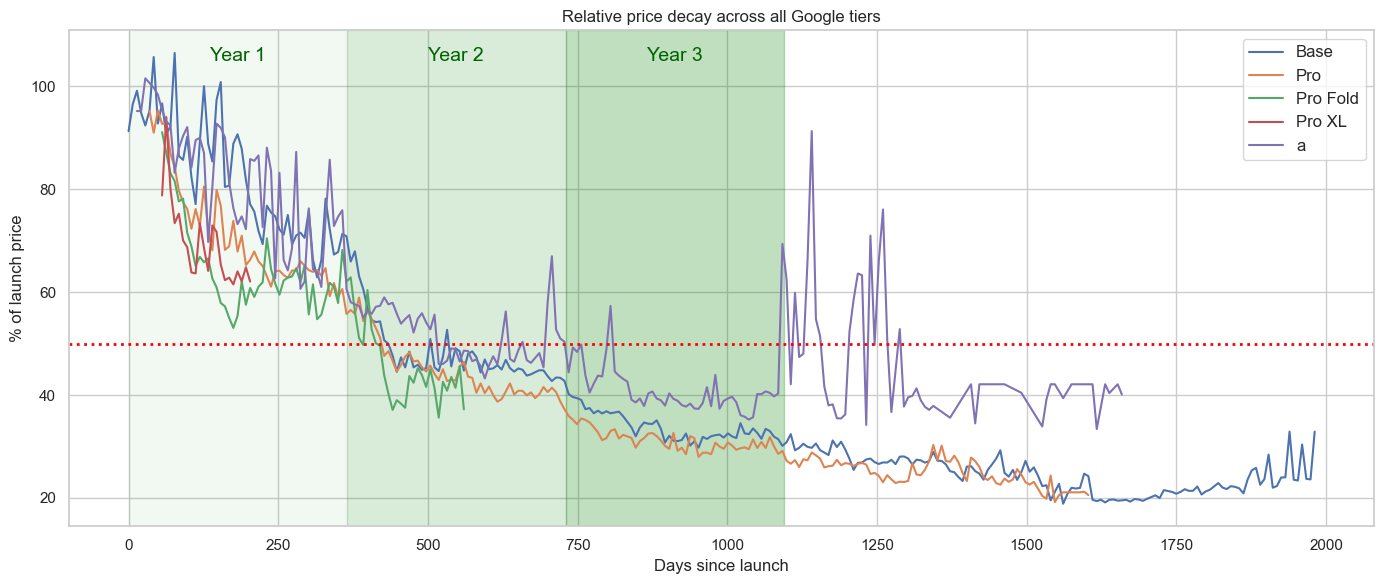

In [26]:
google_tier_df = all_brands_tier_df[all_brands_tier_df['brand'] == 'Google']

plt.subplots(figsize=(14, 6))
sns.lineplot(google_tier_df, x='days_rounded', y='price_pct_of_launch', hue='tier')
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Google tiers')
plt.xlabel('Days since launch')
plt.ylabel('% of launch price')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

Google shows the sharpest polarisation between tiers. The budget 'a' series is the clear leader in value retention, though with notable volatility. The Pro Fold experiences one of the most severe depreciations in the entire dataset, failing to sustain its premium launch value at almost any point in the lifecycle.

---
## Price decay in USD

Percentage drops tell one story. Raw USD values tell another. The charts below show what each brand and tier actually costs at each point in the lifecycle, averaged across all generations, storage options and colours.

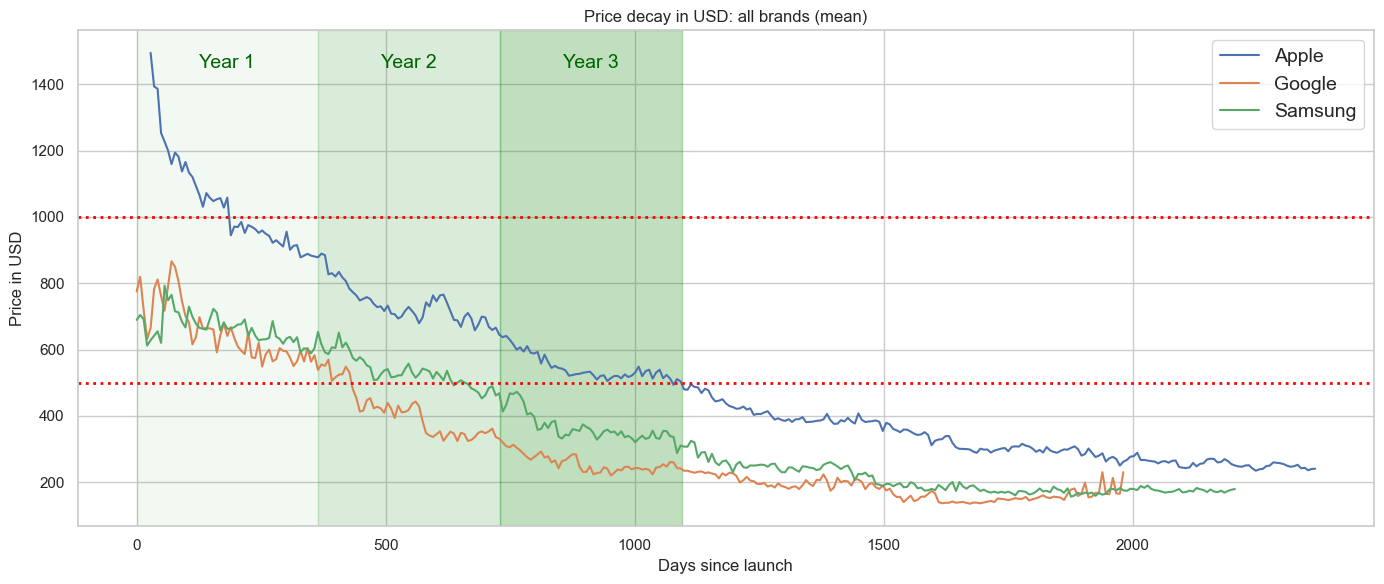

In [27]:
dollar_all_brands_df = df.groupby(['brand', 'days_rounded'])['NEW'].mean().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=dollar_all_brands_df, x='days_rounded', y='NEW', hue='brand')
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD: all brands (mean)')
plt.xlabel('Days since launch')
plt.ylabel('Price in USD')
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1450, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1450, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1450, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

Apple maintains a constant premium of about 200-400 USD over the competition throughout the entire lifecycle. At certain points iPhones can be close to 100% more expensive than direct competitors. The average floor price for an iPhone stabilises around 200-300 USD. Google and Samsung both start at a 700-800 USD baseline. Samsung holds value slightly better after year one, maintaining a roughly 100 USD lead over Google through most of the remaining lifecycle.

#### Brand tier comparisons in USD

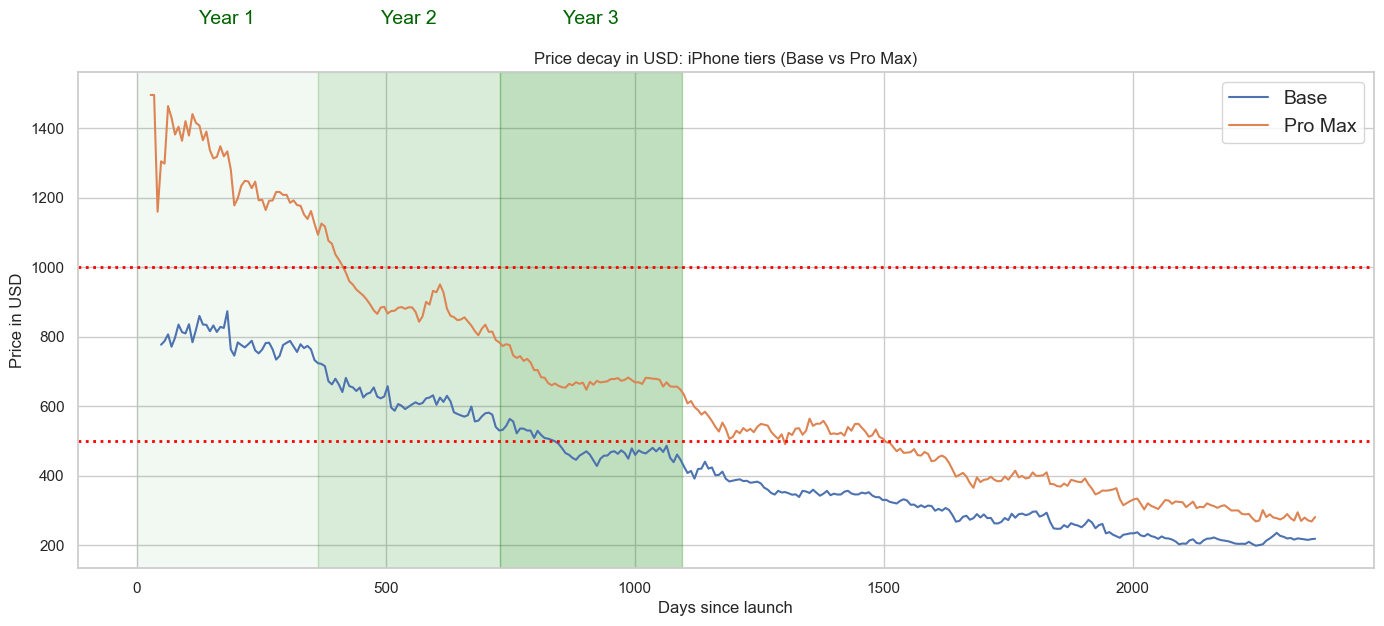

In [28]:
apple_dollar_df = df[(df['brand'] == 'Apple') & (df['tier'].isin(['Base', 'Pro Max']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD: iPhone tiers (Base vs Pro Max)')
plt.xlabel('Days since launch')
plt.ylabel('Price in USD')
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

At launch the Pro Max carries a premium exceeding 600 USD over the Base model (roughly 75%). This gap shrinks rapidly in year one as the Pro Max loses about 30% while the Base loses only 20%, cutting the premium roughly in half to around 300 USD. That 250-300 USD gap then stays relatively stable for the next two years. After 2000 days the Pro Max floors near 280 USD and the Base near 200 USD.

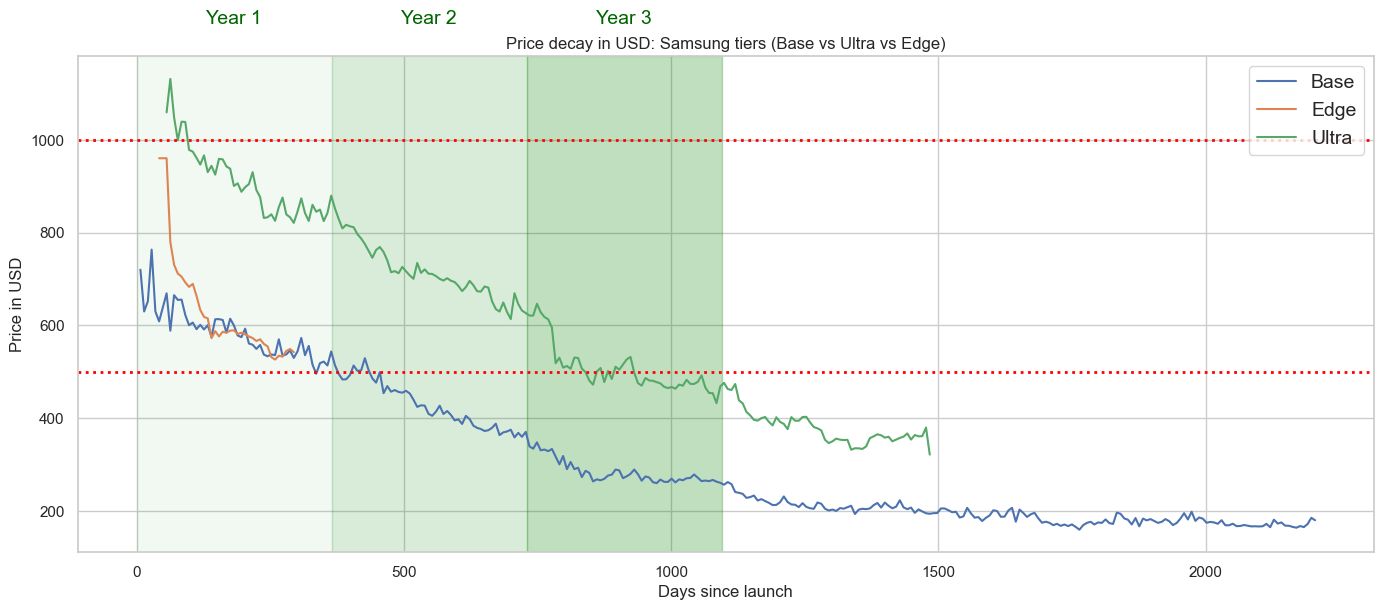

In [29]:
samsung_dollar_df = df[(df['brand'] == 'Samsung') & (df['tier'].isin(['Base', 'Ultra', 'Edge']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=samsung_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD: Samsung tiers (Base vs Ultra vs Edge)')
plt.xlabel('Days since launch')
plt.ylabel('Price in USD')
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1250, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1250, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1250, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

The Edge starts at around 950 USD and plummets to match the Base model within 150-180 days. The Ultra enters near 1150 USD and falls below 1000 USD within months, settling at 800-850 USD after one year. Its premium over the Base decays slower than expected, holding a stable 200-300 USD gap through day 1400.

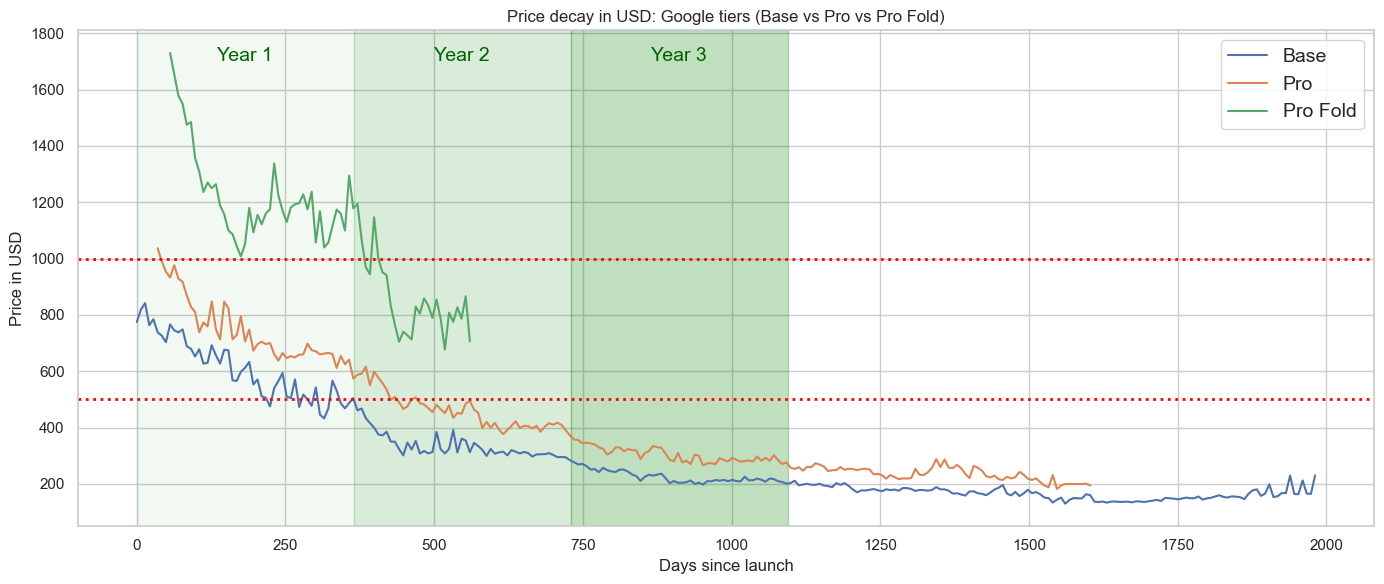

In [30]:
google_dollar_df = df[(df['brand'] == 'Google') & (df['tier'].isin(['Base', 'Pro', 'Pro Fold']))].groupby(['tier', 'days_rounded'])['NEW'].mean().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=google_dollar_df, x='days_rounded', y='NEW', hue='tier')
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD: Google tiers (Base vs Pro vs Pro Fold)')
plt.xlabel('Days since launch')
plt.ylabel('Price in USD')
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')
plt.show()

The Pro Fold enters at 1700 USD and loses over 50% of its value within 500 days, making it the fastest depreciating model in the entire dataset. The Base and Pro models are unusually close to each other, starting with only a 200-250 USD gap that narrows to under 100 USD after year one.

---
## Brand comparison at one year post-launch

Instead of looking at the full decay curve, this takes a snapshot at around 365 days after launch and lines up all generations side by side. It answers which specific models held their value best in year one.

Average 1-year retention by brand:
brand
Apple      80.6
Google     67.9
Samsung    59.3
Name: price_retention, dtype: float64


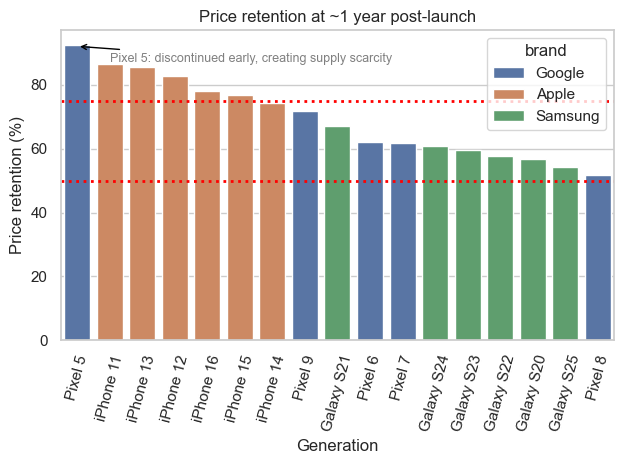

In [31]:
retention_1yr_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = retention_1yr_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention_1yr = retention_1yr_df.groupby('brand')['price_retention'].mean()
print("Average 1-year retention by brand:")
print(brand_retention_1yr.round(1))

order = retention_1yr_df['generation_name'].tolist()
sns.barplot(data=retention_1yr_df, x='generation_name', y='price_retention', hue='brand', order=order)
plt.axhline(75, color='red', linestyle='dotted', linewidth=2)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.annotate(
    text='Pixel 5: discontinued early, creating supply scarcity',
    xy=(0, 92), xytext=(1, 87), color='gray',
    arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
plt.show()

iPhones dominate the top of the chart. The Pixel 5 stands out as a clear anomaly among Google phones. It launched at a relatively low price ($699) and Google discontinued it earlier than expected, which constrained supply and kept its secondary market value unusually high. Other Pixels that launched at higher prices and stayed available longer did not benefit from the same scarcity effect.

---
## Price distribution across the full lifecycle

The decay curves show averages. This boxplot shows the full spread of prices across the entire recorded lifecycle for each brand: median, quartiles, and outliers. It gives a sense of how much variation there is within each brand, not just where the average lands.

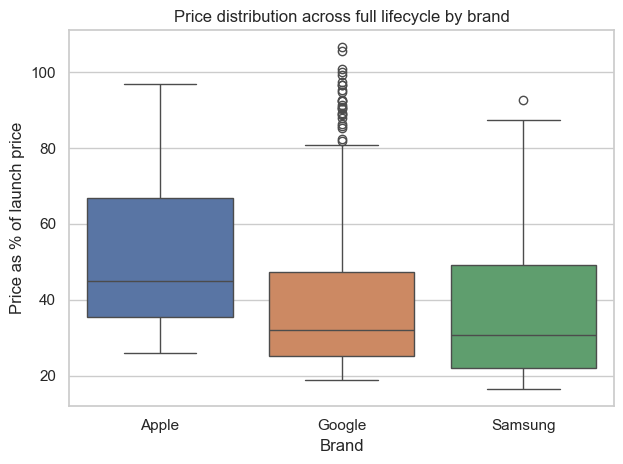

In [32]:
base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

sns.boxplot(data=all_brands_decay_df, x='brand', y='price_pct_of_launch', hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()

Apple clearly leads in median and the IQR sits higher than both competitors. Google and Samsung have similar distributions with minor differences. Google has the highest number of outliers of the three brands.

---
## Sales data pipeline

### Step 1: Clean and prepare

I merged the sales data with the launch reference to get official premiere dates and tier labels, using the same logic as the price pipeline.

In [33]:
ms_df = ms_df.merge(original_launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

print(f"Sales rows after cleaning: {ms_df.shape[0]:,}")
ms_df[['asin', 'submodel_name', 'tier', 'datetime', 'monthly_sold']].head(8)

Sales rows after cleaning: 18,485


,asin,submodel_name,tier,datetime,monthly_sold
0,B011SDYBZW,iPhone 11,Base,2023-10-20 07:04:00,50
1,B011SDYBZW,iPhone 11,Base,2023-11-28 13:34:00,100
2,B011SDYBZW,iPhone 11,Base,2024-01-01 08:42:00,50
3,B011SDYBZW,iPhone 11,Base,2024-01-01 18:16:00,100
4,B011SDYBZW,iPhone 11,Base,2024-01-02 14:56:00,50
5,B011SDYBZW,iPhone 11,Base,2024-06-20 15:22:00,-1
6,B07ZPJ58KN,iPhone 11,Base,2023-10-20 00:52:00,100
7,B07ZPJ58KN,iPhone 11,Base,2023-11-26 05:26:00,200


### Step 2: Resample and aggregate

Because `monthly_sold` is updated periodically throughout the month, I take the last recorded value per month per ASIN using `resample('ME').last()`. This allows to avoid double-counting intermediate updates.

Then I sum across ASINs rather than averaging. Averaging would understate the total activity for models with more variants (e.g. iPhone 16 Pro has 23 ASINs, Galaxy S22 has 8). Summing gives a conservative lower-bound aggregate that is comparable across models regardless of how many variants they have.

Keepa only started tracking this data consistently from late 2023, so there are only about 2.5 years of observations available.

In [34]:
new_ms_df = ms_df.copy().set_index(ms_df['datetime'])
new_ms_df = new_ms_df.groupby('asin').resample('ME').last()
new_ms_df = new_ms_df[(new_ms_df['submodel_name'].notna()) & (new_ms_df['monthly_sold'] >= 0)]
new_ms_df['month_year'] = new_ms_df['datetime'].dt.to_period('M').dt.to_timestamp()

print(f"Months covered: {new_ms_df['month_year'].nunique()}")
print(f"ASINs tracked: {new_ms_df.index.get_level_values('asin').nunique()}")

Months covered: 31
ASINs tracked: 354


---
## Monthly sales by brand

Starting with the broadest view: total sales indicator per brand per month.

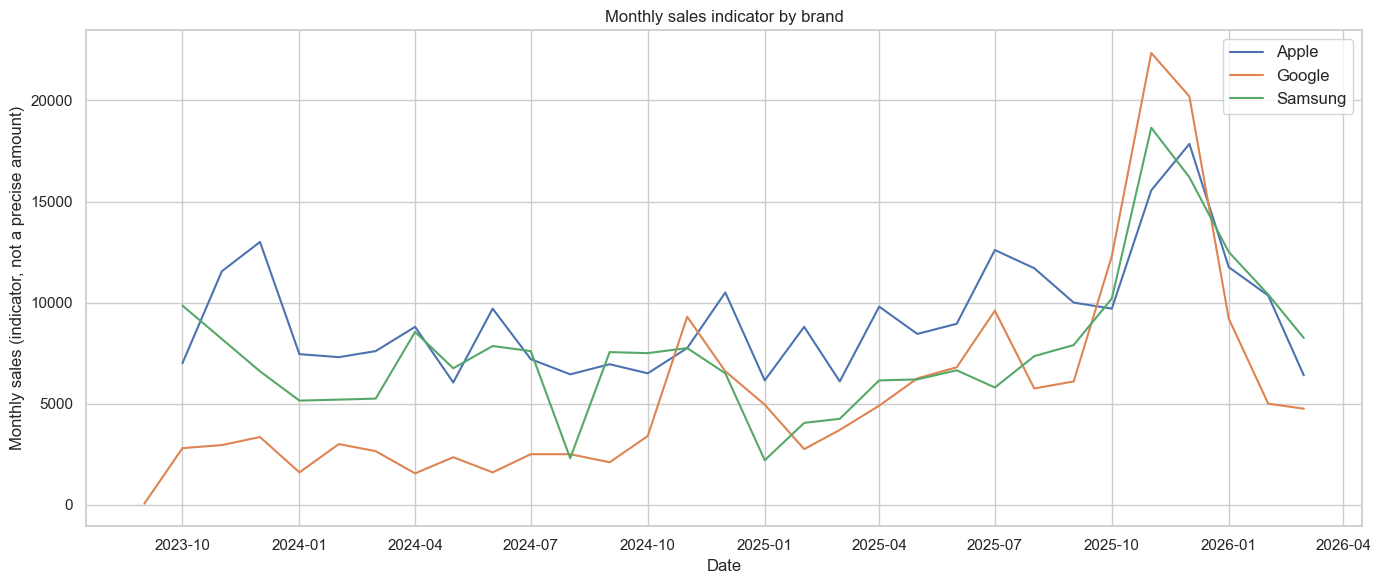

In [35]:
brand_ms_df = new_ms_df.groupby(['brand', 'month_year'])['monthly_sold'].sum().reset_index()

plt.subplots(figsize=(14, 6))
sns.lineplot(data=brand_ms_df, x='month_year', y='monthly_sold', hue='brand')
plt.title('Monthly sales indicator by brand')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

Apple leads overall but the differences are not large and it often runs neck and neck with Samsung. Google shows its first major spike in Q4 2024, then again in July 2025 and Q4 2025. All three brands show a clear spike in Q4 2025. Google and Apple also spike in July 2025, which aligns with Prime Day timing.

---
## Monthly sales by tier

Breaking down by tier within each brand to see which model types drive secondary market demand.

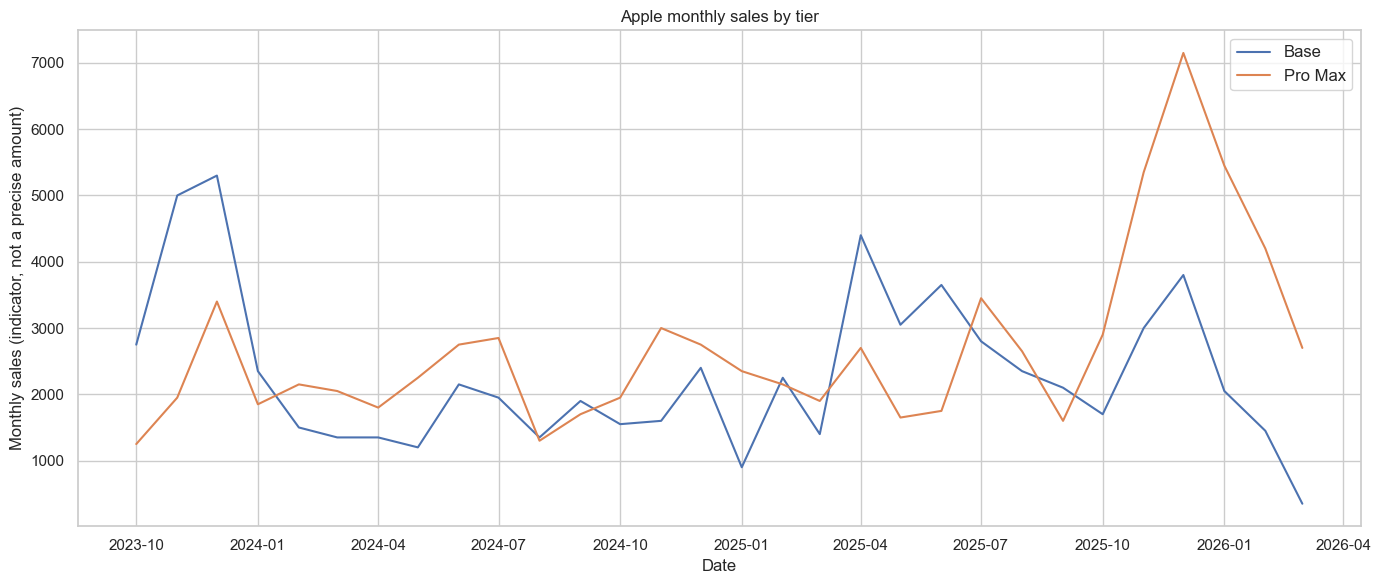

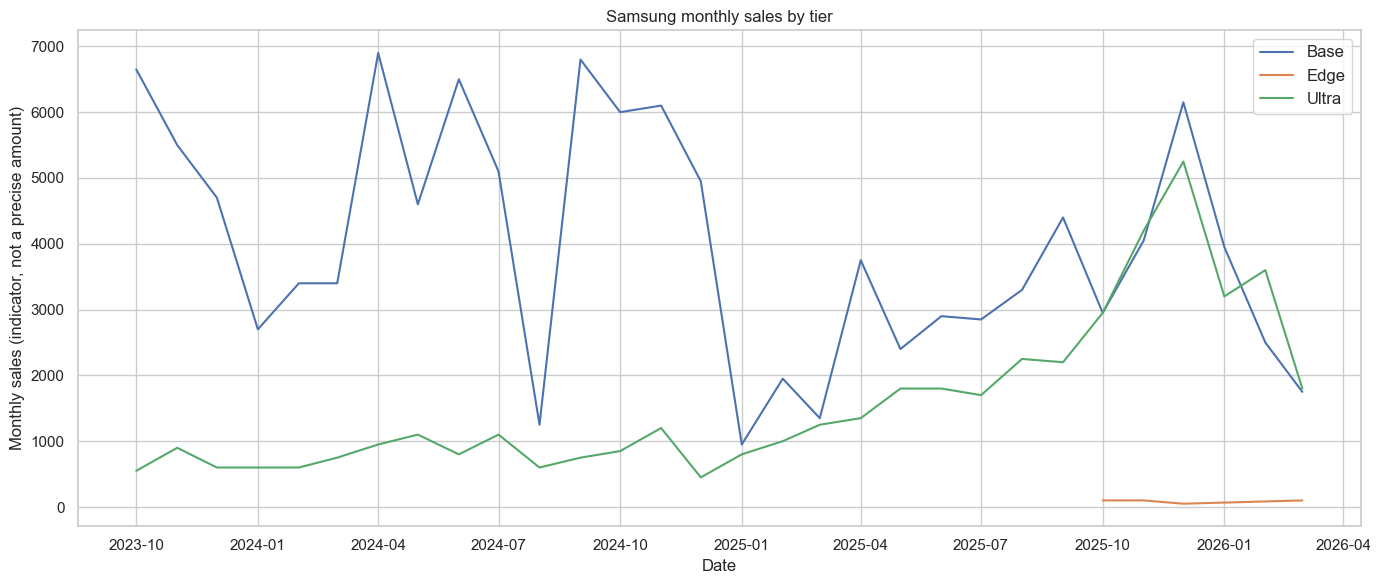

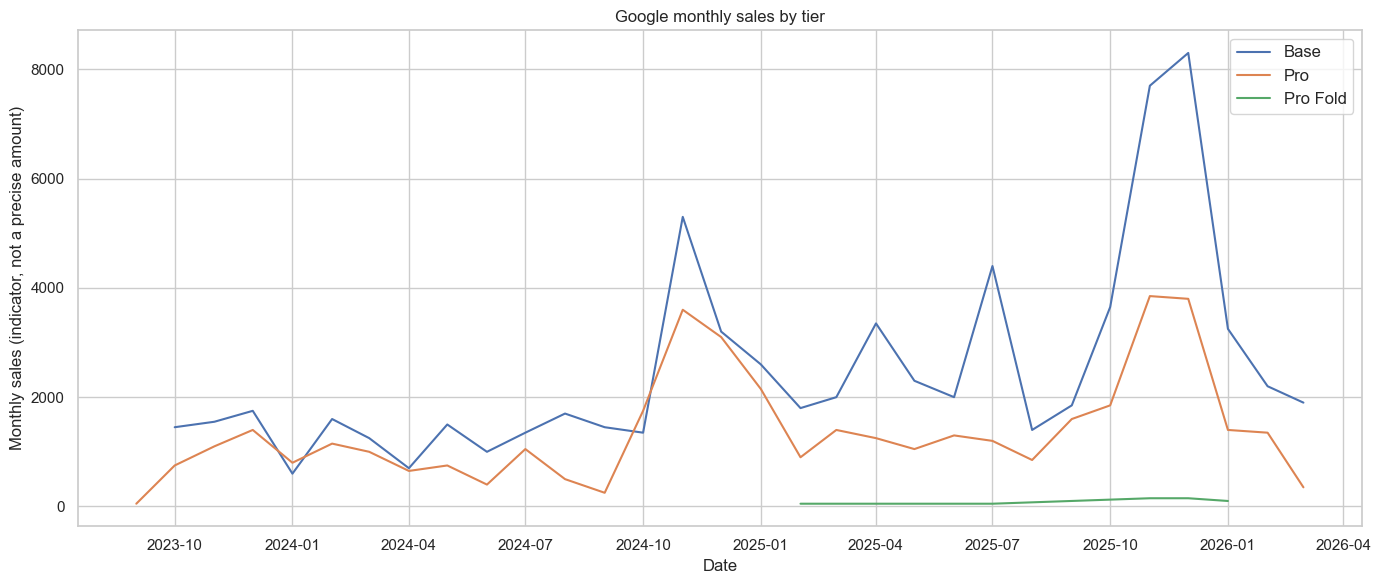

In [36]:
brand_tier_ms_df = new_ms_df.groupby(['brand', 'tier', 'month_year'])['monthly_sold'].sum().reset_index()

apple_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Apple') & (brand_tier_ms_df['tier'].isin(['Base', 'Pro Max']))]
plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Apple monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

samsung_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Samsung') & (brand_tier_ms_df['tier'].isin(['Base', 'Ultra', 'Edge']))]
plt.subplots(figsize=(14, 6))
sns.lineplot(data=samsung_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Samsung monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

google_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Google') & (brand_tier_ms_df['tier'].isin(['Base', 'Pro', 'Pro Fold']))]
plt.subplots(figsize=(14, 6))
sns.lineplot(data=google_ms_df, x='month_year', y='monthly_sold', hue='tier')
plt.title('Google monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

Apple's Base and Pro Max tiers lead interchangeably throughout the observation period. A longer data window would be needed to draw firm conclusions about which tier drives the secondary market more consistently.

Samsung's base tier leads in sales volume for most of the period, though Ultra shows a notable spike in Q4 2025. The Edge variant, already flagged for its aggressive price decay, confirms the pattern on the sales side as well and sits far below both alternatives throughout.

Google's Base and Pro models run closely together for most of the time, which aligns with the narrow price gap between them. The Base spikes sharply in Q4 2025. The Pro Fold shows consistently low sales volume throughout, confirming its niche positioning.

---
## iPhone base models: sales over time

Looking at real calendar dates rather than days since launch lets us see seasonal patterns and the effect of new launches on older model demand.

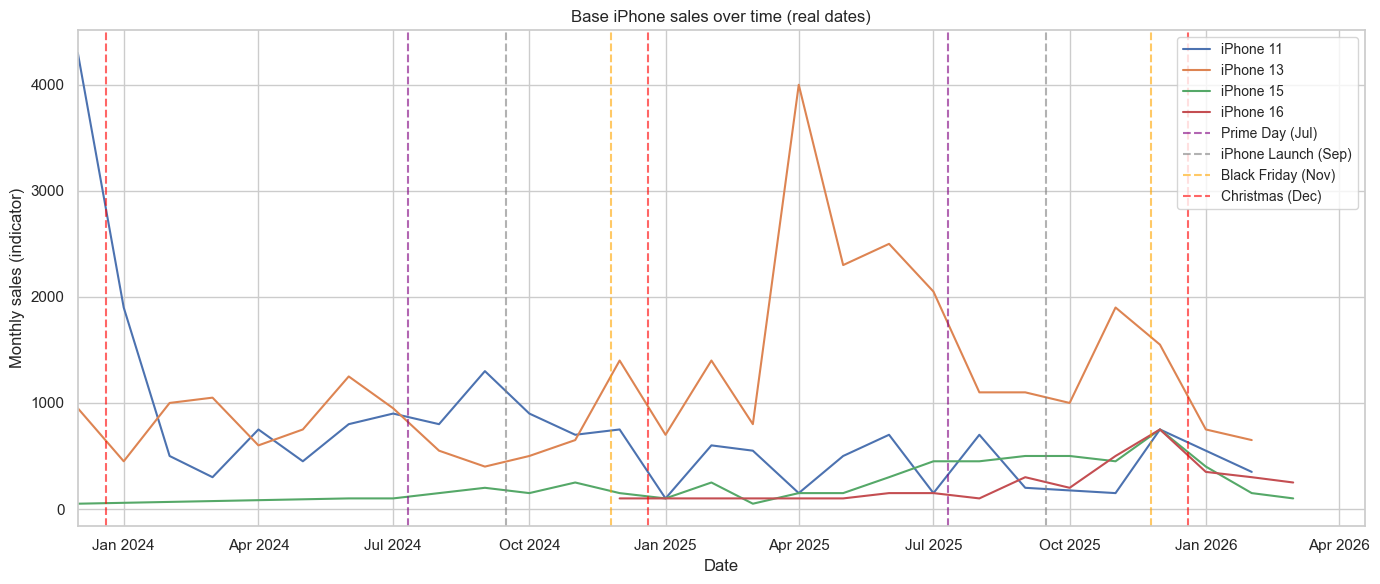

In [37]:
submodel_ms_df = new_ms_df.groupby(['brand', 'submodel_name', 'tier', 'generation_name', 'month_year'])['monthly_sold'].sum().reset_index()
apple_base_ms_df = submodel_ms_df[(submodel_ms_df['brand'] == 'Apple') & (submodel_ms_df['tier'] == 'Base')]

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=apple_base_ms_df, x='month_year', y='monthly_sold', hue='generation_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Base iPhone sales over time (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator)')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))
plt.tight_layout()
plt.show()

## iPhone 13: the secondary market king
iPhone 11 and 13 go head to head through 2024. In 2025 iPhone 11 drops significantly while iPhone 13 surges, establishing it as the clear leader of the refurbished Apple market right now.

Newer models show a slower start and seem more driven by specific triggers. iPhone 15 remains flat in year one, picks up when iPhone 16 launches, then spikes in July 2025. iPhone 16 follows a similar pattern but finishes its first year considerably stronger than the 15. The launch of a new iPhone generation consistently acts as a catalyst for predecessor sales.

All of these patterns should be treated with some caution given we are only looking at two years of data.

---
## iPhone submodel sales: 11, 13 and 15

With the generation-level picture clear, let's look at how individual submodels within each generation perform.

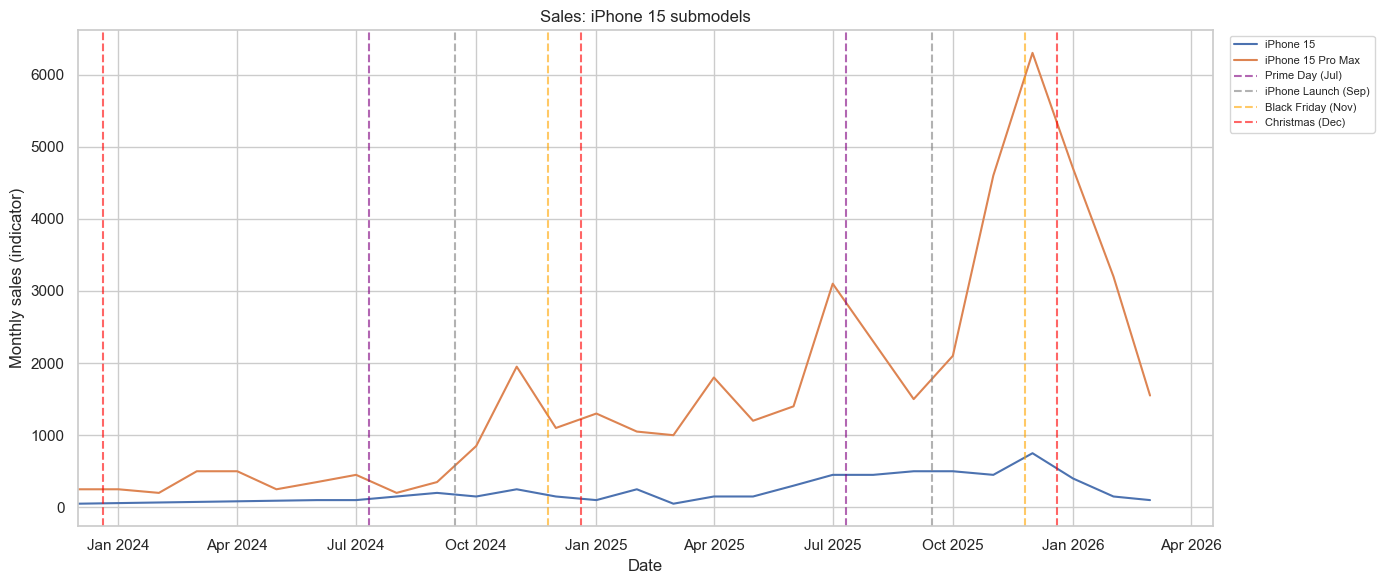

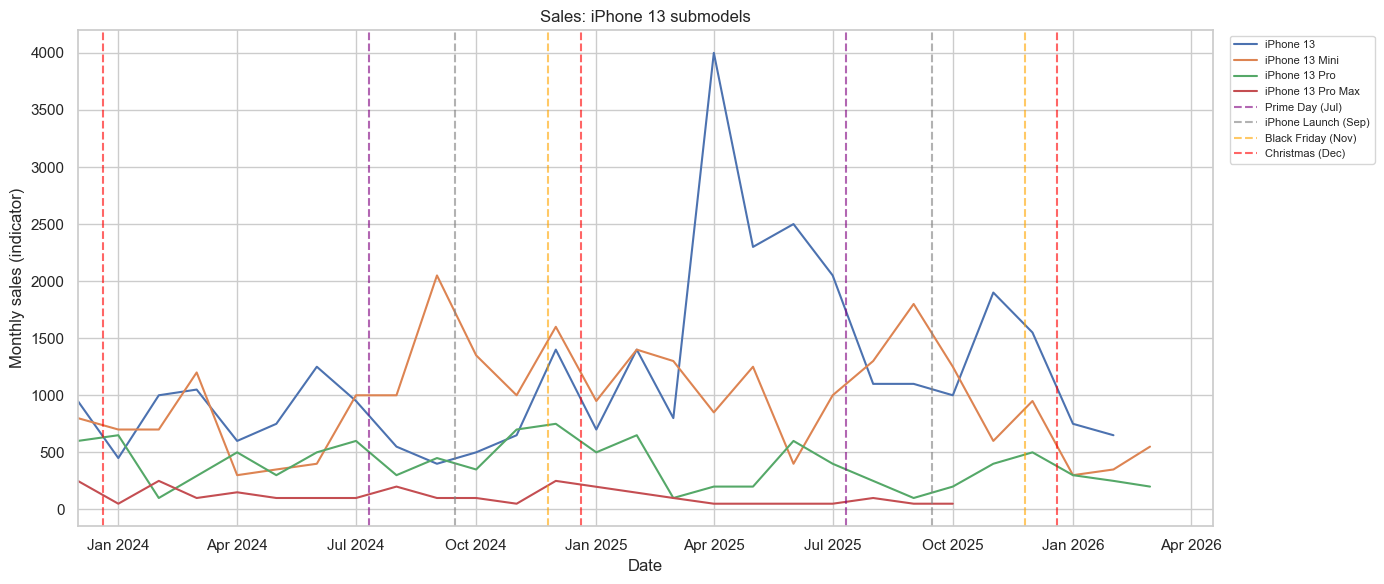

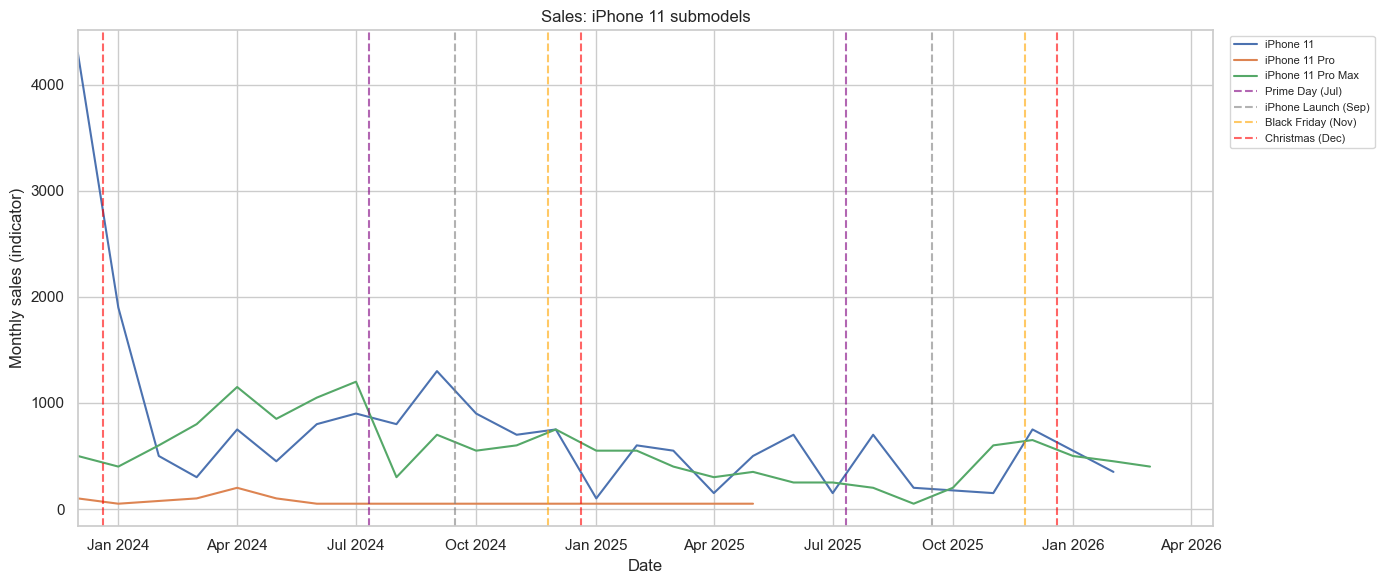

In [38]:
iphone15_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 15']
iphone13_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 13']
iphone11_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 11']

def add_vlines(ax):
    ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
    ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
    ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday (Nov)')
    ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
    for year in range(2024, 2026):
        ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
        ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

for gen_df, title in [
    (iphone15_ms_df, 'iPhone 15 submodels'),
    (iphone13_ms_df, 'iPhone 13 submodels'),
    (iphone11_ms_df, 'iPhone 11 submodels'),
]:
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.lineplot(data=gen_df, x='month_year', y='monthly_sold', hue='submodel_name', ax=ax)
    add_vlines(ax)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_title(f'Sales: {title}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly sales (indicator)')
    ax.set_xlim(left=pd.Timestamp('2023-12-01'))
    plt.tight_layout()
    plt.show()

## iPhone 15: Pro Max dominance in year two
The Pro Max is volatile, spiking sharply after the iPhone 16 launch and even more after the iPhone 17. Buyers appear to wait out the first year, knowing the sharpest price drop happens there, then jump in when the next generation launches and drives the price down further. The base iPhone 15 stays flat and stable throughout.

## iPhone 13: opposite behaviour
Here the roles are reversed. The Pro and Pro Max act as the stable anchor while the base model and Mini drive sales with higher volatility. Buyers at this price point seem to be optimising for value rather than flagship specs.

## iPhone 11: convergence point
The base model and Pro Max run almost neck and neck here. The price gap between them has shrunk to around 100 USD, with the Pro Max sitting near 300 USD. At that point the extra 100 USD for the top-tier flagship becomes a much easier decision for most buyers.

---
# Key findings

- **All brands' sales spike in Q4.** For iPhones, the end of September brings a new generation launch, followed by Black Friday in November and Christmas in December.

- **Apple retains value best.** The 50% barrier comes around 900 days for Apple vs roughly 500 days for Samsung and 420 for Google. This tendency continues throughout the lifecycle, with Apple flooring at 26-28% of launch price vs 16-17% for Samsung and 20% for Google.

- **iPhone 13 is the undisputed secondary market king.** The best-selling iPhone generation on the refurbished market right now, likely because it offers the right balance of price and hardware capability.

- **Buying 1-2 years after launch offers strong value.** At the one-year mark, iPhones retain roughly 70-75% of their launch price on average, dropping to around 50% by year two. The hardware hasn't meaningfully aged by then. Sales data, while limited, seems to support this as a real buying window. More data would be needed to draw firm conclusions.

- **Renewed Premium holds its value better than standard Renewed.** For iPhones the gap averages around 10.2 percentage points and stays fairly stable throughout the lifecycle. It is not just a launch-window premium.

- **New iPhone launches seem to catalyze secondary market sales for predecessors.** Each new generation appears to trigger a measurable uptick in sales for the immediate predecessor. This should be treated as directional given only two full seasonal cycles are available.

- **The Pixel 5 is an anomaly.** It outperforms every other Google model at the one-year mark. A low launch price combined with early discontinuation constrained supply and kept secondary market value elevated longer than expected.

- **Some niche variants depreciate fastest.** The Samsung Galaxy Edge and Google Pixel Pro Fold stand out as commercially unsuccessful variants. Both suffer some of the sharpest price declines in the dataset and low sales volume despite premium positioning. The exact drivers are speculative and consumer research would be needed to confirm.

- **Budget-conscious buyers drive the secondary market for older generations.** In the iPhone 13 lineup the base model and Mini lead in sales, not the Pro Max. However for iPhone 11, where the price gap has narrowed significantly, the two sell almost equally. Once the premium shrinks enough, buyers simply opt for the better hardware.

*Together, the data paint a clear picture of how quickly and how differently each brand and tier loses value on the secondary market.*